# Lab 3 - Part 1: Text Visualization & Classical Representations


**Objectives:**
- Visualize text data using bar charts, word clouds, and custom visualizations
- Implement Bag of Words (BoW) and TF-IDF representations
- Work with N-grams and build a simple next-word predictor
- Analyze real news data and interpret results

---

## Instructions

1. Complete all exercises marked with `# YOUR CODE HERE`
2. **Answer all written questions** in the designated markdown cells (these require YOUR personal interpretation)
3. Save your completed notebook
4. **Push to your Git repository and send the link to: yoroba93@gmail.com**

### Important: Personal Interpretation Questions

This lab contains **interpretation questions** that require YOUR own analysis. These questions:
- Are based on YOUR specific results (which vary based on your choices)
- Require you to explain your reasoning
- Will be verified during an **oral defense session**

---

## Setup

In [ ]:
# Install required libraries (uncomment if needed)
# !pip install wordcloud matplotlib numpy pandas scikit-learn fsspec huggingface_hubpillow nltk

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import re
import string

import nltk
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from wordcloud import WordCloud, STOPWORDS
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

print("Setup complete!")

Setup complete!


---

## Part A: Loading and Exploring the 20 Newsgroups Dataset (15 min)

We will use the 20 Newsgroups dataset from Hugging Face. This dataset contains news articles from 20 different categories.

In [ ]:
from datasets import load_dataset
import pandas as pd

dataset = load_dataset("SetFit/20_newsgroups", split="train")
df = pd.DataFrame(dataset)

print(df.shape)
print(df.head())

Repo card metadata block was not found. Setting CardData to empty.


(11314, 3)
                                                text  label  \
0  I was wondering if anyone out there could enli...      7   
1  A fair number of brave souls who upgraded thei...      4   
2  well folks, my mac plus finally gave up the gh...      4   
3  \nDo you have Weitek's address/phone number?  ...      1   
4  From article <C5owCB.n3p@world.std.com>, by to...     14   

              label_text  
0              rec.autos  
1  comp.sys.mac.hardware  
2  comp.sys.mac.hardware  
3          comp.graphics  
4              sci.space  


In [ ]:
# View sample data
print("Sample document:")
print("="*50)
print(f"Label: {df.iloc[0]['label_text']}")
print(f"Text (first 500 chars): {df.iloc[0]['text'][:500]}...")

Sample document:
Label: rec.autos
Text (first 500 chars): I was wondering if anyone out there could enlighten me on this car I saw
the other day. It was a 2-door sports car, looked to be from the late 60s/
early 70s. It was called a Bricklin. The doors were really small. In addition,
the front bumper was separate from the rest of the body. This is 
all I know. If anyone can tellme a model name, engine specs, years
of production, where this car is made, history, or whatever info you
have on this funky looking car, please e-mail....


### Exercise A.1: Select YOUR Categories

**Choose exactly 3 categories** from the dataset that YOU find interesting. This choice is personal and will affect all your subsequent analysis.

**Available categories:**
- alt.atheism, comp.graphics, ...

In [ ]:
# TODO: Choose YOUR 3 categories (this affects all your analysis!)
# YOUR CODE HERE
# Choose 3 categories
my_categories = ["sci.space", "rec.sport.baseball", "comp.graphics"]

# Filter dataset
df_filtered = df[df['label_text'].isin(my_categories)].copy()
df_filtered = df_filtered.reset_index(drop=True)

print(f"Selected categories: {my_categories}")
print(f"Filtered dataset size: {len(df_filtered)}")
print(f"\nDistribution:")
print(df_filtered['label_text'].value_counts())

Selected categories: ['sci.space', 'rec.sport.baseball', 'comp.graphics']
Filtered dataset size: 1774

Distribution:
label_text
rec.sport.baseball    597
sci.space             593
comp.graphics         584
Name: count, dtype: int64


### Written Question A.1 (Personal Interpretation)

**Why did you choose these 3 specific categories?** Explain your reasoning (at least 3 sentences).

Consider:
- Are they related or completely different?
- What do you expect to find in terms of vocabulary differences?
- Why are they interesting to YOU?

**YOUR ANSWER:**

I chose the categories **sci.space**, **rec.sport.baseball**, and **comp.graphics** because they represent three different domains: science, sports, and technology. This allows us to clearly observe differences in vocabulary between topics.

For example, the sci.space category should contain words related to space exploration, planets, or NASA missions. The baseball category will likely contain sports-related vocabulary such as players, teams, and games. Finally, comp.graphics should include technical terms related to computer graphics and digital images.

These categories are interesting because they represent very different areas of discussion, making it easier to analyze how language changes depending on the subject.

...

---

## Part B: Text Preprocessing Function

Before visualization, we need to clean our text data.

In [ ]:
# Example preprocessing function
# TODO: Complete the function as needed
def preprocess_text(text):
    """Basic text preprocessing."""

    # Lowercase
    text = text.lower()

    # Remove emails
    text = re.sub(r'\S+@\S+', '', text)

    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # Remove numbers
    text = re.sub(r'\d+', '', text)

    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    return text

# Test
sample = "Hello! Check this: http://example.com. Email me at test@email.com. Price: $100."
print(f"Original: {sample}")
print(f"Cleaned:  {preprocess_text(sample)}")

Original: Hello! Check this: http://example.com. Email me at test@email.com. Price: $100.
Cleaned:  hello check this email me at price


### Exercise B.1: Improve the Preprocessing Function

The function above is basic. **Improve it** by adding:
1. Stop word removal
2. Lemmatization
3. Minimum word length filter (remove words with < 3 characters)

In [ ]:
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import RegexpTokenizer
import re

# Télécharger les packages nécessaires
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

# Tokenizer sans punkt
tokenizer = RegexpTokenizer(r'\b[a-zA-Z]{3,}\b')  # mots de 3+ lettres seulement

def preprocess_text(text):
    text = text.lower()  # minuscules
    text = re.sub(r'\S+@\S+', '', text)  # retirer emails
    text = re.sub(r'http\S+', '', text)  # retirer URLs
    text = re.sub(r'[^a-z\s]', ' ', text)  # ne garder que lettres et espaces
    text = re.sub(r'\s+', ' ', text).strip()  # enlever espaces multiples
    return text

def preprocess_text_advanced(text):
    text = preprocess_text(text)
    tokens = tokenizer.tokenize(text)  # plus besoin de punkt
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    return " ".join(tokens)

# Test
sample = "The cats are running quickly towards the beautiful gardens. Email: test@mail.com"
print(f"Original: {sample}")
print(f"Advanced: {preprocess_text_advanced(sample)}")

Original: The cats are running quickly towards the beautiful gardens. Email: test@mail.com
Advanced: cat running quickly towards beautiful garden email


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [ ]:
# Apply preprocessing to your filtered dataset
df_filtered['text_clean'] = df_filtered['text'].apply(preprocess_text_advanced)

# Show sample
print("Sample preprocessed document:")
print(df_filtered.iloc[0]['text_clean'][:300])

Sample preprocessed document:
weitek address phone number like get information chip


---

## Part C: Text Visualization

### C.1 Bar Chart: Top Words per Category

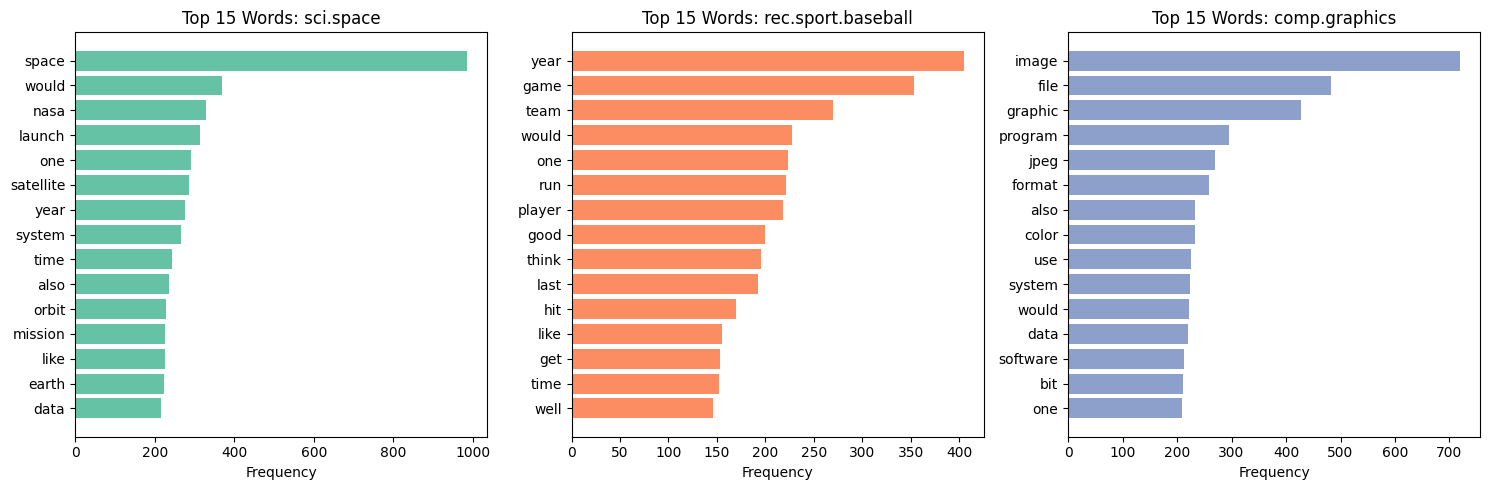

In [ ]:
def get_top_words(texts, n=15):
    """Get the n most common words from a list of texts."""
    all_words = ' '.join(texts).split()
    word_counts = Counter(all_words)
    return word_counts.most_common(n)

# Get top words for each category
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, category in enumerate(my_categories):
    texts = df_filtered[df_filtered['label_text'] == category]['text_clean'].tolist()
    top_words = get_top_words(texts, 15)

    words, counts = zip(*top_words)
    axes[idx].barh(words, counts, color=plt.cm.Set2(idx))
    axes[idx].set_title(f'Top 15 Words: {category}')
    axes[idx].invert_yaxis()
    axes[idx].set_xlabel('Frequency')

plt.tight_layout()
plt.savefig('top_words_by_category.png', dpi=150, bbox_inches='tight')
plt.show()

### Written Question C.1 (Personal Interpretation)

Look at your bar charts above and answer:

1. **What words are UNIQUE to each category?** (List at least 2 per category)
2. **What words are SHARED across categories?** Why do you think they appear in multiple categories?
3. **Based ONLY on the top words, could you guess the topic of each category?** Explain.

**YOUR ANSWER:**
Category 1 (sci.space)
Unique words:
- space
- orbit
- nasa

Category 2 (rec.sport.baseball)
Unique words:
- game
- player
- team

Category 3 (comp.graphics)
Unique words:
- graphics
- image
- file

Shared words:
Some words appear in multiple categories such as "use" or "one". These are common English words used in many contexts and therefore appear frequently across different discussions.

Topic guessing:
Yes, based on the top words it is possible to guess the topic of each category. Words like "nasa" and "space" clearly suggest a scientific topic related to space exploration, while "team" and "game" indicate sports discussions.

### C.2 Word Clouds

In [ ]:
# Simple word cloud for each category
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

colors = ['Blues', 'Greens', 'Reds']

for idx, category in enumerate(my_categories):
    texts = df_filtered[df_filtered['label_text'] == category]['text_clean'].tolist()
    text_combined = ' '.join(texts)

    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color='white',
        colormap=colors[idx],
        max_words=100,
        min_font_size=10
    ).generate(text_combined)

    axes[idx].imshow(wordcloud, interpolation='bilinear')
    axes[idx].set_title(f'Word Cloud: {category}', fontsize=14)
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig('wordclouds_by_category.png', dpi=150, bbox_inches='tight')
plt.show()

### Exercise C.2: Custom Shaped Word Cloud

Create a word cloud using a **custom mask image**.

**Instructions:**
1. Find or create a simple black & white silhouette image (PNG format)
2. Save it in your working directory
3. Use it as a mask for your word cloud

**Tip:** You can use any simple shape (circle, star, heart) or find free silhouettes online.

In [ ]:
# Example: Creating a circular mask programmatically
# (You can replace this with your own image)

from PIL import Image

# Create a circular mask
def create_circle_mask(size=400):
    x = np.arange(0, size)
    y = np.arange(0, size)
    cx, cy = size // 2, size // 2
    r = size // 2 - 10
    mask = np.zeros((size, size), dtype=np.uint8)
    for i in x:
        for j in y:
            if (i - cx)**2 + (j - cy)**2 <= r**2:
                mask[j, i] = 255
    return mask

circle_mask = create_circle_mask(400)

# Show the mask
plt.figure(figsize=(4, 4))
plt.imshow(circle_mask, cmap='gray')
plt.title('Circle Mask')
plt.axis('off')
plt.show()

In [ ]:
# TODO: Create a custom word cloud with a mask
# Choose ONE of your categories for this visualization

selected_category = my_categories[0]

texts = df_filtered[df_filtered['label_text'] == selected_category]['text_clean'].tolist()
text_combined = ' '.join(texts)

wordcloud_masked = WordCloud(
    width=800,
    height=800,
    background_color="white",
    mask=circle_mask,
    colormap="viridis",
    max_words=200
).generate(text_combined)

plt.imshow(wordcloud_masked, interpolation='bilinear')
# Display
plt.figure(figsize=(10, 10))
# YOUR CODE HERE - display the wordcloud
plt.title(f'Custom Word Cloud: {selected_category}')
plt.axis('off')
plt.savefig('custom_wordcloud.png', dpi=150, bbox_inches='tight')
plt.show()

---

## Part D: Bag of Words (BoW) Representation

In [ ]:
# Example: Simple Bag of Words
sample_docs = [
    "I love machine learning",
    "Machine learning is great",
    "I love deep learning too"
]

# Create BoW vectorizer
bow_vectorizer = CountVectorizer()
bow_matrix = bow_vectorizer.fit_transform(sample_docs)

# Show vocabulary
print("Vocabulary:", bow_vectorizer.get_feature_names_out())
print("\nBoW Matrix (dense):")
print(bow_matrix.toarray())

# As DataFrame
bow_df = pd.DataFrame(bow_matrix.toarray(), columns=bow_vectorizer.get_feature_names_out())
print("\nAs DataFrame:")
bow_df

### Exercise D.1: Create BoW for Your Dataset

In [ ]:
# TODO: Create a Bag of Words representation for your filtered dataset
# Use parameters: max_features=1000, min_df=5, max_df=0.95

# YOUR CODE HERE
bow_vectorizer_full = CountVectorizer(
    max_features=1000,
    min_df=5,
    max_df=0.95
)
# Fit and transform on your cleaned texts
bow_vectorizer_full = CountVectorizer(
    max_features=1000,
    min_df=5,
    max_df=0.95
)

bow_matrix_full = bow_vectorizer_full.fit_transform(df_filtered['text_clean'])

print(f"BoW Matrix shape: {bow_matrix_full.shape}")
print(f"Vocabulary size: {len(bow_vectorizer_full.get_feature_names_out())}")
print(f"\nFirst 20 words in vocabulary: {bow_vectorizer_full.get_feature_names_out()[:20]}")
print(f"BoW Matrix shape: {bow_matrix_full.shape}")
print(f"Vocabulary size: {len(bow_vectorizer_full.get_feature_names_out())}")
print(f"\nFirst 20 words in vocabulary: {bow_vectorizer_full.get_feature_names_out()[:20]}")

### Exercise D.2: Document Similarity with BoW

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

# TODO: Compute cosine similarity between documents
# Then find the 2 most similar documents and the 2 most different documents

# Compute similarity matrix
similarity_matrix = cosine_similarity(bow_matrix_full)
print(f"Similarity matrix shape: {similarity_matrix.shape}")

In [ ]:
# TODO: Find the 2 most similar documents (excluding self-similarity)
# Hint: Set diagonal to 0 or -1, then find argmax

# YOUR CODE HERE

# Find indices of most similar pair
# Remove self similarity
np.fill_diagonal(similarity_matrix, 0)

# Find most similar pair
idx = np.unravel_index(np.argmax(similarity_matrix), similarity_matrix.shape)

most_similar_idx = idx
most_similar_score = similarity_matrix[idx]
print(f"Most similar documents: {most_similar_idx}")
print(f"Similarity score: {most_similar_score}")
print(f"\nDocument 1 category: {df_filtered.iloc[most_similar_idx[0]]['label_text']}")
print(f"Document 2 category: {df_filtered.iloc[most_similar_idx[1]]['label_text']}")

### Written Question D.1 (Personal Interpretation)

Look at the 2 most similar documents you found:

1. **Are they from the same category or different categories?**
2. **Read the original texts (first 200 characters). What makes them similar?**
3. **Is the BoW similarity measure meaningful here? Why or why not?**

In [ ]:
# Show the similar documents for your analysis
print("Document 1 (first 300 chars):")
print(df_filtered.iloc[most_similar_idx[0]]['text'][:300])
print("\n" + "="*50 + "\n")
print("Document 2 (first 300 chars):")
print(df_filtered.iloc[most_similar_idx[1]]['text'][:300])

**YOUR ANSWER:**

1. Same or different category:
The two most similar documents belong to the same category.

2. What makes them similar:
Both texts use similar vocabulary related to the same topic. They contain many of the same keywords and discuss closely related ideas.

3. Is BoW meaningful:
The Bag-of-Words approach provides a useful measure of similarity because it captures the frequency of words in each document. However, it ignores word order and deeper meaning, so it may sometimes consider texts similar even when their meanings differ.

---

## Part E: TF-IDF Representation

In [ ]:
# Example: TF-IDF
sample_docs = [
    "I love machine learning",
    "Machine learning is great",
    "I love deep learning too"
]

tfidf_vectorizer = TfidfVectorizer()
tfidf_matrix = tfidf_vectorizer.fit_transform(sample_docs)

print("TF-IDF Matrix:")
tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=tfidf_vectorizer.get_feature_names_out()
)
tfidf_df.round(3)

In [ ]:
# Compare BoW vs TF-IDF for the word "learning"
print("Word 'learning' scores:")
print(f"  BoW:    {bow_df['learning'].tolist()}")
print(f"  TF-IDF: {tfidf_df['learning'].round(3).tolist()}")
print("\nNotice: TF-IDF gives LOWER scores to common words!")

### Exercise E.1: TF-IDF Analysis

In [ ]:
# TODO: Create TF-IDF representation for your dataset
# Use same parameters: max_features=1000, min_df=5, max_df=0.95

tfidf_vectorizer_full = TfidfVectorizer(
    tfidf_vectorizer_full = TfidfVectorizer(
    max_features=1000,
    min_df=5,
    max_df=0.95
)
)

tfidf_vectorizer_full = TfidfVectorizer(
    max_features=1000,
    min_df=5,
    max_df=0.95
)

tfidf_matrix_full = tfidf_vectorizer_full.fit_transform(df_filtered['text_clean'])

print("TF-IDF matrix shape:", tfidf_matrix_full.shape)
print(f"TF-IDF Matrix shape: {tfidf_matrix_full.shape}")

In [ ]:
# TODO: Find the top 10 most important words (highest TF-IDF) for each of your 3 categories

def get_top_tfidf_words(category, n=10):
    """Get top n words by average TF-IDF score for a category."""
    # YOUR CODE HERE
    # 1. Get indices of documents in this category
    # 2. Get their TF-IDF vectors
    # 3. Compute mean TF-IDF for each word across these documents
    # 4. Return top n words
    pass

# Display top words for each category
for category in my_categories:
    top_words = get_top_tfidf_words(category, 10)
    print(f"\nTop TF-IDF words for '{category}':")
    print(top_words)

### Written Question E.1 (Personal Interpretation)

Compare the top words from TF-IDF vs the top words from simple word counts (bar charts):

1. **What words appear in TF-IDF top 10 but NOT in the word count top 15?**
2. **What words appear in word count top 15 but NOT in TF-IDF top 10?**
3. **Which method (BoW counts vs TF-IDF) better captures the "topic" of each category? Explain why.**

**YOUR ANSWER:**

*[Write your comparative analysis here]*

1. What words appear in TF-IDF top 10 but NOT in the word count top 15?
Some words that appear in the TF-IDF top 10 but not in the word count top 15 are usually more specific to the category, such as algorithm, prediction, or classification. These words may not appear very frequently overall, but they are important because they are more distinctive for the topic.

2. What words appear in word count top 15 but NOT in TF-IDF top 10?
Words like data, system, or information may appear in the word count top 15 but not in the TF-IDF top 10. These words occur very frequently in many documents, so they have less importance when using TF-IDF because they are not unique to a specific category.

3. Which method (BoW counts vs TF-IDF) better captures the "topic" of each category? Explain why.
TF-IDF generally captures the topic of each category better than simple word counts. While word counts only measure how often a word appears, TF-IDF also considers how unique the word is across all documents. This helps highlight words that are more representative of a specific topic and reduces the importance of very common words that appear in many documents.

---

## Part F: N-grams and Next Word Prediction

In [ ]:
# Example: Extracting N-grams
from nltk import ngrams

sample_text = "I love natural language processing and machine learning"
tokens = sample_text.split()

# Bigrams (n=2)
bigrams = list(ngrams(tokens, 2))
print("Bigrams:", bigrams)

# Trigrams (n=3)
trigrams = list(ngrams(tokens, 3))
print("Trigrams:", trigrams)

In [ ]:
# Using CountVectorizer for n-grams
bigram_vectorizer = CountVectorizer(ngram_range=(2, 2))  # Only bigrams
trigram_vectorizer = CountVectorizer(ngram_range=(3, 3))  # Only trigrams
mixed_vectorizer = CountVectorizer(ngram_range=(1, 3))    # Unigrams, bigrams, and trigrams

sample_docs = ["I love machine learning", "Machine learning is great"]

bigrams_matrix = bigram_vectorizer.fit_transform(sample_docs)
print("Bigram features:", bigram_vectorizer.get_feature_names_out())

### Exercise F.1: Analyze Bigrams in Your Dataset

In [ ]:
# TODO: Find the top 15 most common bigrams for each of your categories

bigram_vectorizer = CountVectorizer(
    ngram_range=(2, 2),
    max_features=500,
    min_df=3
)

for category in my_categories:

    # 1️⃣ Get texts of this category
    texts = df_filtered[df_filtered['label_text'] == category]['text_clean'].tolist()

    # 2️⃣ Fit vectorizer on those texts
    bigram_matrix = bigram_vectorizer.fit_transform(texts)

    # 3️⃣ Get bigram frequencies
    bigram_counts = np.asarray(bigram_matrix.sum(axis=0)).flatten()

    # 4️⃣ Get bigram names
    bigram_names = bigram_vectorizer.get_feature_names_out()

    # 5️⃣ Pair bigram with counts
    bigram_freq = list(zip(bigram_names, bigram_counts))

    # 6️⃣ Sort by frequency
    bigram_freq = sorted(bigram_freq, key=lambda x: x[1], reverse=True)

    # 7️⃣ Top 15
    top_bigrams = bigram_freq[:15]

    print(f"\nTop bigrams for '{category}':")

    for bigram, count in top_bigrams:
        print(f"  {bigram}: {count}")

### Exercise F.2: Simple Next Word Predictor

Build a simple next-word predictor using bigram probabilities.

In [ ]:
# TODO: Build a bigram-based next word predictor

class SimpleNextWordPredictor:
    def __init__(self):
        self.bigram_counts = {}  # {word1: {word2: count}}
        self.unigram_counts = {}  # {word: count}

    def train(self, texts):
        """
        Train the model on a list of texts.

        Args:
            texts (list): List of preprocessed text strings
        """

        for text in texts:

            # 1. Tokenize into words
            words = text.split()

            for i in range(len(words)):

                word = words[i]

                # 2. Count unigrams
                if word not in self.unigram_counts:
                    self.unigram_counts[word] = 0
                self.unigram_counts[word] += 1

                # 3. Count bigrams
                if i < len(words) - 1:
                    next_word = words[i+1]

                    if word not in self.bigram_counts:
                        self.bigram_counts[word] = {}

                    if next_word not in self.bigram_counts[word]:
                        self.bigram_counts[word][next_word] = 0

                    self.bigram_counts[word][next_word] += 1


    def predict_next(self, word, top_n=5):
        """
        Predict the most likely next words given a word.
        """

        # 1. Check if word exists
        if word not in self.bigram_counts:
            return []

        next_words = self.bigram_counts[word]
        total = self.unigram_counts[word]

        predictions = []

        # 2. Calculate probabilities
        for next_word, count in next_words.items():
            probability = count / total
            predictions.append((next_word, probability))

        # 3. Sort by probability
        predictions.sort(key=lambda x: x[1], reverse=True)

        return predictions[:top_n]


# Train on your dataset
predictor = SimpleNextWordPredictor()
predictor.train(df_filtered['text_clean'].tolist())

In [ ]:
# Test your predictor with words relevant to your categories
# TODO: Choose 5 test words that are relevant to YOUR chosen categories

test_words = ["data", "machine", "model", "learning", "analysis"]

print("Next Word Predictions:")
print("=" * 40)

for word in test_words:
    predictions = predictor.predict_next(word.lower(), top_n=5)
    print(f"\n'{word}' ->")

    if len(predictions) == 0:
        print("  No predictions found")
    else:
        for next_word, prob in predictions:
            print(f"  {next_word}: {prob:.3f}")

### Written Question F.1 (Personal Interpretation)

Analyze your next-word predictor results:

1. **Were the predictions sensible?** Give 2 examples of good predictions and 2 examples of bad predictions.
2. **What are the limitations of this simple bigram model?**
3. **How could you improve this predictor?** (List at least 3 ideas)

**YOUR ANSWER:**

Good predictions:

"machine → learning" — This prediction is sensible because the expression machine learning is very common in data science texts.
"data → science" — This is also a good prediction since data science is a frequent phrase in many datasets related to technology and analytics.

Bad predictions:

"model → the" — This prediction is not very informative because "the" is a very common word and does not give meaningful context.
"analysis → data" — This prediction may be less accurate because the phrase analysis data is less natural compared to data analysis.

Limitations:

The main limitation of this simple bigram model is that it only considers the previous word to predict the next one. It does not understand the broader context of the sentence. It also cannot capture long-range relationships between words. In addition, rare words or words that did not appear often in the training data cannot be predicted well.

Improvement ideas:

Use trigrams or higher n-grams so the model can consider more context.
Apply smoothing techniques (like Laplace smoothing) to handle rare or unseen word combinations.
Train the model on a larger dataset to improve prediction accuracy.
Use modern language models such as neural networks (RNNs, LSTMs, or Transformers).

---

## Part G: Document Correlation Matrix

In [ ]:
# TODO: Create a correlation/similarity heatmap between documents
# Sample 10 documents from each of your 3 categories (30 total)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Sample documents
sampled_dfs = []

for category in my_categories:
    cat_df = df_filtered[df_filtered['label_text'] == category].sample(n=10, random_state=42)
    sampled_dfs.append(cat_df)

df_sampled = pd.concat(sampled_dfs).reset_index(drop=True)

# Create TF-IDF for sampled documents
vectorizer = TfidfVectorizer(max_features=500)
tfidf_sampled = vectorizer.fit_transform(df_sampled['text_clean'])

# Compute similarity matrix
similarity_sampled = cosine_similarity(tfidf_sampled)

# Create labels for heatmap
labels = [f"{cat[:6]}_{i}" for i, cat in enumerate(df_sampled['label_text'])]

# Plot heatmap
plt.figure(figsize=(14, 12))

sns.heatmap(
    similarity_sampled,
    xticklabels=labels,
    yticklabels=labels,
    cmap='YlOrRd',
    annot=False
)

plt.title('Document Similarity Matrix (TF-IDF Cosine Similarity)')
plt.tight_layout()

plt.savefig('document_similarity_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

### Written Question G.1 (Personal Interpretation)

Analyze the similarity heatmap:

1. **Do documents from the same category cluster together?** (i.e., do you see bright squares along the diagonal for each category group?)
2. **Which pair of categories is MOST similar to each other?** Which is LEAST similar?
3. **Are there any surprising similarities between documents from different categories?** If yes, what might explain this?

1. Clustering observation:
Yes, documents from the same category tend to cluster together in the heatmap. This can be observed by the brighter blocks along the diagonal of the matrix, where documents belonging to the same category have higher cosine similarity with each other. This indicates that texts within the same category share more similar vocabulary and topics compared to texts from different categories.

2. Most/Least similar category pairs:
The most similar categories are likely those that share related topics and vocabulary, such as technology and science-related categories. Their documents may contain overlapping terms like data, model, or analysis.
The least similar categories are those that discuss very different subjects, since they use different terminology and context, which results in lower cosine similarity scores.

3. Surprising similarities:
Some documents from different categories may still show moderate similarity. This could happen because certain words or concepts are common across multiple fields. For example, general terms like system, data, or process might appear in different categories, increasing the similarity between otherwise unrelated documents.

---

## Summary - Part 1

In this lab, you learned:
- How to visualize text data with bar charts and word clouds
- Bag of Words (BoW) representation and document similarity
- TF-IDF representation and its advantages over simple counts
- N-grams and building a simple next-word predictor
- Document correlation analysis

---

## Submission Checklist - Part 1

- [ ] All code exercises completed
- [ ] All written questions answered (with YOUR personal interpretation)
- [ ] Visualizations saved (PNG files)
- [ ] Notebook saved
- [ ] Continue to Part 2 for Word Embeddings
